In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# Spectrogram: 基本

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/intro_spectrogram.ipynb)

このノートブックでは、`gwexpy` で新しく導入された `SpectrogramList` および `SpectrogramDict` クラスの使い方を紹介します。

これらのクラスは、複数のスペクトログラムデータ（`gwpy.spectrogram.Spectrogram`）をまとめて管理し、一括して処理（クロップ、再ビン化、プロットなど）を行うためのコンテナです。
時系列データを扱う `TimeSeriesList` / `TimeSeriesDict` と似たインターフェースを持っていますが、2次元データ（時間 × 周波数）を扱う点が特徴です。

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt

from gwexpy.noise.wave import gaussian, sine
from gwexpy.spectrogram import SpectrogramDict, SpectrogramList

## 1. データの準備

まずはデモ用のスペクトログラムデータを作成します。
ここでは、異なる周波数のサイン波を含む時系列データを生成し、それを `spectrogram()` メソッドで変換して使用します。

In [3]:
# Create sample data
duration = 20  # seconds
sample_rate = 128  # Hz

# Create sine waves at 10Hz, 30Hz, 50Hz (+noise)
noise_amp = 0.1


def make_signal(freq, name):
    s = sine(duration=duration, sample_rate=sample_rate, frequency=freq, amplitude=1.0)
    n = gaussian(duration=duration, sample_rate=sample_rate, std=noise_amp)
    ts = s + n
    ts.name = name
    ts.override_unit("strain")
    return ts


ts1 = make_signal(10, "Signal 10Hz")
ts2 = make_signal(30, "Signal 30Hz")
ts3 = make_signal(50, "Signal 50Hz")

# Calculate spectrograms (stride=2s, fftlength=1s)
# Specify nproc=1 for stability with serial execution
spec1 = ts1.spectrogram(2, fftlength=1, overlap=0.5, nproc=1)
spec2 = ts2.spectrogram(2, fftlength=1, overlap=0.5, nproc=1)
spec3 = ts3.spectrogram(2, fftlength=1, overlap=0.5, nproc=1)

print("Spectrogram shape:", spec1.shape)
print("Time range:", spec1.xspan)
print("Freq range:", spec1.yspan)

Spectrogram shape: (10, 65)
Time range: [0.0 ... 20.0)
Freq range: [0.0 ... 65.0)


## 2. SpectrogramList の基本操作

`SpectrogramList` はリストのように振る舞いますが、格納できるのは `Spectrogram` オブジェクトのみです。
初期化時にリストを渡すか、`append()` メソッドで追加します。

In [4]:
# Create a list
spec_list = SpectrogramList([spec1, spec2])

# Append
spec_list.append(spec3)

print(f"List length: {len(spec_list)}")
print(f"Items: {[s.name for s in spec_list]}")

List length: 3
Items: ['Signal 10Hz', 'Signal 30Hz', 'Signal 50Hz']


### バッチ処理: 時間軸の切り出し (`crop`)

リスト内のすべてのスペクトログラムに対して、一括で時間軸の切り出しを行います。
**注意:** スペクトログラムはデータ量が大きいため、クロップなどの操作は元のデータを変更せず、新しいオブジェクト（コピー）を返すことがあります。

In [5]:
# Crop to 5-15 second range
cropped_list = spec_list.crop(5, 15)

print("Original range:", spec_list[0].xspan)
print("Cropped range:", cropped_list[0].xspan)

Original range: [0.0 ... 20.0)
Cropped range: [4.0 ... 14.0)


### バッチ処理: 周波数軸の切り出し (`crop_frequencies`)

gwpyの `Spectrogram` に互換性のあるメソッドがあればそれを使用し、なければ周波数軸を指定してフィルタリングを行います。

In [6]:
# Crop to 0Hz - 40Hz range
freq_cropped = spec_list.crop_frequencies(0, 40)

print("Original yspan:", spec_list[0].yspan)
print("Cropped yspan:", freq_cropped[0].yspan)
# The third element containing the 50Hz signal will also have out-of-range portions cut

Original yspan: [0.0 ... 65.0)
Cropped yspan: [0.0 ... 40.0)


## 3. SpectrogramDict の利用

名前（キー）付きで管理したい場合は `SpectrogramDict` が便利です。

In [7]:
spec_dict = SpectrogramDict({"low_freq": spec1, "mid_freq": spec2, "high_freq": spec3})

print("Keys:", list(spec_dict.keys()))

Keys: ['low_freq', 'mid_freq', 'high_freq']


## 4. 可視化 (`plot`)

リストや辞書の `.plot()` メソッドを呼ぶと、含まれるすべてのスペクトログラムをまとめてプロットできます。
内部では `gwpy.plot.Plot` を使用しています。

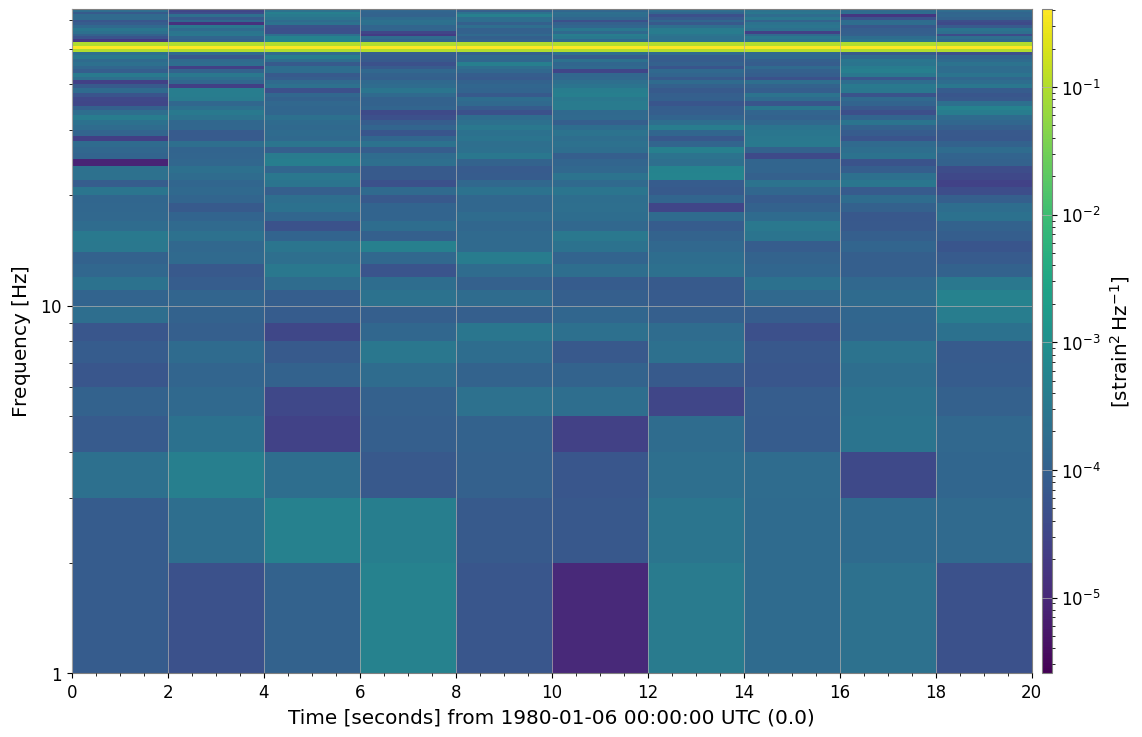

In [8]:
# Batch plotting
# Setting sharex=True, sharey=True shares axes for easier comparison
plot = spec_dict.plot(figsize=(12, 8), sharex=True, sharey=True)
plt.show()

## 5. 行列形式への変換と Deep Learning 連携

`to_matrix()` を使用すると、各スペクトログラムを積み重ねた 3次元配列 `(Channels, Time, Frequency)` を持つ `SpectrogramMatrix` オブジェクトを作成できます。

これは機械学習モデル（PyTorch, TensorFlowなど）への入力を作成する際に非常に便利です。

In [9]:
matrix = spec_list.to_matrix()

print("Matrix Type:", type(matrix))
print("Matrix Shape:", matrix.shape)
print("  (N_channels, N_time_steps, N_freq_bins)")

# Accessing attributes
print("Time axis shape:", matrix.times.shape)
print("Freq axis shape:", matrix.frequencies.shape)

Matrix Type: <class 'gwexpy.spectrogram.matrix.SpectrogramMatrix'>
Matrix Shape: (3, 10, 65)
  (N_channels, N_time_steps, N_freq_bins)
Time axis shape: (10,)
Freq axis shape: (65,)


PyTorchやCuPyがインストールされていれば、そのままTensor等に変換可能です。

```python
# PyTorch Tensorへの変換
# tensor = matrix.to_torch()
```

## よくある落とし穴と失敗モード

- **色の明るさをそのまま絶対振幅だと読むこと**: 正規化、カラースケール、対数表示の設定が違うと、同じデータでも印象が大きく変わります。
- **時間分解能と周波数分解能を同時に高く見積もること**: `fftlength`、`stride`、window の選び方にはトレードオフがあり、画像で細く見える構造がそのまま物理的に鋭いとは限りません。
- **軸のそろっていない図を直接比較すること**: `sharex` / `sharey` や表示範囲が一致していないと、差がスペクトル構造ではなく描画条件から生じます。
- **切り出し後の結果を新しい推定だと誤解すること**: `crop` や `crop_frequencies` は表示・保持範囲を制限する操作であり、推定パラメータを変えて再計算したわけではありません。
- **行列化した後に軸の意味を見失うこと**: `SpectrogramMatrix` は `(Channels, Time, Frequency)` の順です。軸入れ替えを誤ると、もっともらしいが誤った ML 入力になります。
- **ノイズ床を無視してピークを解釈すること**: 明るい帯が見えても、背景ノイズ、リーケージ、推定条件との相対比較なしには有意性を判断できません。


## まとめ

これで `SpectrogramList` と `SpectrogramDict` の基本的な使い方の紹介を終わります。
大量のスペクトログラムデータを一括で前処理したり、比較プロットを行う際にぜひ活用してください。